In [116]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.integrate as integ
#from functions import *

import requests
request = requests.get("https://raw.githubusercontent.com/nsfuss/AMOC-Senior-Project/refs/heads/main/functions.py")
with open("functions.py", "wb") as f:
  f.write(request.content)
from functions import *

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rc('xtick.minor', visible=True)
mpl.rc('ytick.minor', visible=True)


## Goal:

Have H increase linearly w.r.t time and then decrease linearly w.r.t time, graph Q vs T for this scenario. It is unlikely we will see the expected spike as H decreases to the critical point. <br>
 
Now let $q$ be defined by the differential $\tau \frac{dq}{dt} = -q + k|\alpha \Delta T - \beta \Delta S|$ integrate this to get q as H increases given the known relationship $\frac{d \Delta S}{dt} = 2H - 2|q| \Delta S$ <br>
Need to figure out what $\tau$ should be here, Cyrus guesses in the range of 1-2 centuries

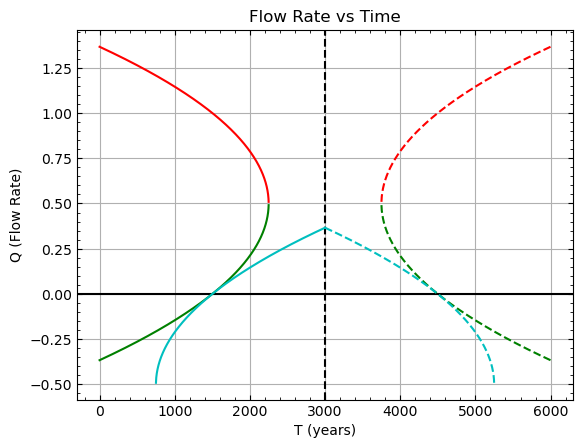

In [117]:
beta = 0.5
alpha = 2
delT = 1
k = 0.5
Args = [beta,alpha,delT,k] # Define arguments

q0, q1, q2, times, extra= q_H2(Args, -2, 2, 6000)


plt.axhline(0, color='k')
plt.axvline(3000,color='k',ls='--')
# Graphing the increasing and decreasing sections of 
plt.plot(times[0], q0[0] , color='r',label='First Stable Inc')
plt.plot(times[1], q0[1] , color='r',ls='--',label='First Stable Dec')

plt.plot(times[2], q1[0], color='g',label='Unstable Inc')
plt.plot(times[3], q1[1], color='g',ls='--',label='Unstable Dec')

plt.plot(times[4], q2[0], color='c',label='Second Stable Inc')
plt.plot(times[5], q2[1], color='c',ls='--',label='Second Stable Dec')

#plt.xlim(1200,2000)
plt.title('Flow Rate vs Time')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.grid()
#plt.legend()


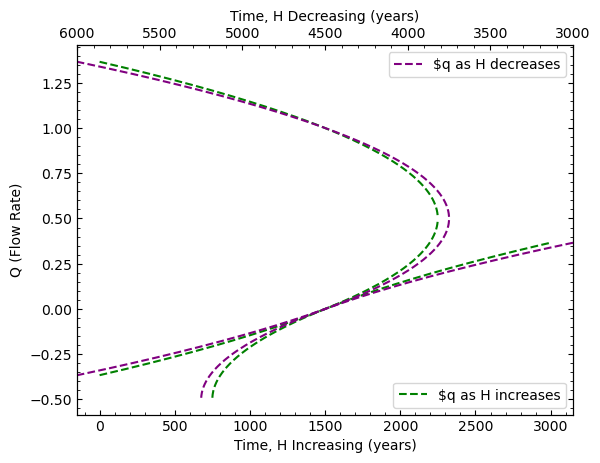

In [118]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(times[0], q0[0], color='g',ls='--',label=r'$q as H increases')
ax1.plot(times[2], q1[0], color='g',ls='--')
ax1.plot(times[4], q2[0], color='g',ls='--')
ax1.legend(loc='lower right')
ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.set_xlim((6000,3000))
ax2.plot(times[1], q0[1], color='purple',ls='--',label=r'$q as H decreases')
ax2.plot(times[3], q1[1], color='purple',ls='--')
ax2.plot(times[5], q2[1] , color='purple',ls='--')
ax2.legend(loc='upper right')

In [136]:
def Hs(t, n, H_start, H_end):
    dH = (H_end - H_start) / (n/2)
    if t <= (n/2):
        H = H_start + (dH * t)
    elif t > (n/2):
        H = H_end - (dH * (t-n/2))
    return H

def dqdtnoQ(t, y, args, n, H_start, H_end):
    '''
    System of equation for AMOC with DS as functions of time

    Parameters:
    t: float, time
    y: float, DS
    args: array: [beta, alpha, delT, k]
    n: intended number of samples

    Output:
    dydt: array same shape as y where dydt[i] is the time derivative of y[i]
    '''

    dydt = 2 * Hs(t, n, H_start, H_end) - 2 * np.absolute(args[3]*(args[1]*args[2] - args[0]*y)) * y
    
    return dydt

In [137]:
n = 6000
H_start = -2
H_end = 2
DSinitial = dSi0 = Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H_start*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0]

y0 = np.array([DSinitial])

solQ = integ.solve_ivp(dqdtnoQ,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end]), t_eval=(np.arange(n)))

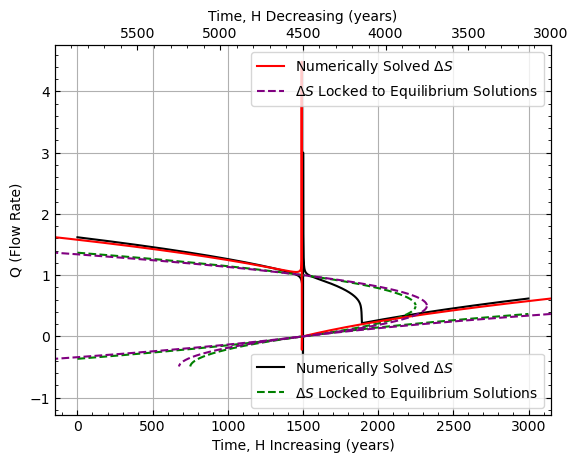

In [121]:
H = np.zeros(6000)
H[:3000] = np.linspace(H_start,H_end,(n//2))
H[3000:] = np.flip(np.linspace(H_start,H_end,(n//2)))
Qs = H / solQ.y[0]

fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(solQ.t[:3000], Qs[:3000], color='k',label=r'Numerically Solved $\Delta S$')
ax1.plot(times[0], q0[0], color='g',ls='--',label=r'$\Delta S$ Locked to Equilibrium Solutions')
ax1.plot(times[2], q1[0], color='g',ls='--')
ax1.plot(times[4], q2[0], color='g',ls='--')
ax1.legend(loc='lower right')
ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(solQ.t[3000:],Qs[3000:], color='r',label=r'Numerically Solved $\Delta S$')
ax2.set_xlim((solQ.t[-1],solQ.t[(n//2)]))
ax2.plot(times[1], q0[1], color='purple',ls='--',label=r'$\Delta S$ Locked to Equilibrium Solutions')
ax2.plot(times[3], q1[1], color='purple',ls='--')
ax2.plot(times[5], q2[1] , color='purple',ls='--')
ax2.legend(loc='upper right')

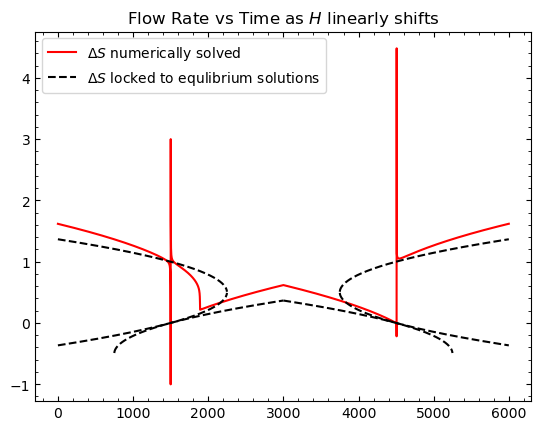

In [122]:
plt.plot(solQ.t,Qs,color='r',label=r'$\Delta S$ numerically solved')

plt.plot(times[1], q0[1] , color='k',ls='--')
plt.plot(times[2], q1[0], color='k',ls='--')
plt.plot(times[3], q1[1], color='k',ls='--')
plt.plot(times[4], q2[0], color='k',ls='--')
plt.plot(times[5], q2[1], color='k',ls='--')
plt.plot(times[0], q0[0] , color='k',ls='--',label=r'$\Delta S$ locked to equlibrium solutions')

plt.title(r'Flow Rate vs Time as $H$ linearly shifts')
plt.legend()


## Redefining $q$ as $q(t)$

This means resolving the system but now instead of just $\Delta S$ being a function of time, $q$ is now also a function of time. 




In [123]:
def dqdtTest(t, y, args, n, H_start, H_end, tau):
    '''
    System of equation for AMOC with q, DS, and H as functions of time

    Parameters:
    t: float, time
    y: array of DS, q, and H: y[0]=DS, y[1]=q, y[2]=H
    args: array: [beta, alpha, delT, k]
    n: intended number of samples

    Output:
    dydt: array same shape as y where dydt[i] is the time derivative of y[i]
    '''
    dydt = np.zeros_like(y)
    dydt[0] = 2 * Hs(t, n, H_start, H_end) - 2 * np.absolute(y[1]) * y[0]
    dydt[1] = (-y[1] + args[3] * np.absolute(args[1]*args[2] - args[0]*y[0])) / tau
    
    return dydt

In [124]:
n = 6000
H_start = -2
H_end = 2
qinital = q0[0][0]
DSinitial = dSi0 = Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H_start*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0]

y0 = np.array([DSinitial, qinital])

sol = integ.solve_ivp(dqdtTest,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end, 10]), t_eval=(np.arange(n)))

sol1 = integ.solve_ivp(dqdtTest,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end, 100]), t_eval=(np.arange(n)))

sol2 = integ.solve_ivp(dqdtTest,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end, 500]), t_eval=(np.arange(n)))

sol3 = integ.solve_ivp(dqdtTest,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end, 1000]), t_eval=(np.arange(n)))


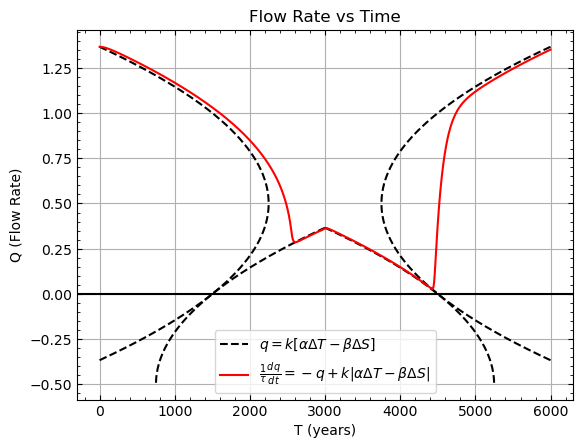

In [ ]:


plt.axhline(0, color='k')
# Graphing the increasing and decreasing sections of calculations done with q = |

plt.plot(times[0], q0[0] , color='k',ls='--',label=r'$q=k[\alpha \Delta T - \beta \Delta S]$')
plt.plot(times[1], q0[1] , color='k',ls='--')
plt.plot(times[2], q1[0], color='k',ls='--')
plt.plot(times[3], q1[1], color='k',ls='--')
plt.plot(times[4], q2[0], color='k',ls='--')
plt.plot(times[5], q2[1], color='k',ls='--')

plt.plot(sol1.t, sol1.y[1], color = 'r',label=r'$\frac{1}{\tau} \frac{dq}{dt}=-q + k|\alpha \Delta T - \beta \Delta S|$')
#plt.xlim(2000,6000)
plt.title('Flow Rate vs Time')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.legend()
plt.grid()
#plt.legend()


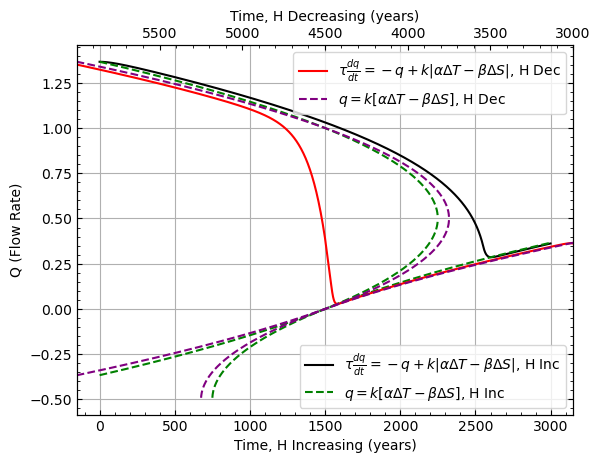

In [149]:
# Setting up the plot with increasing H going left to right and decreasing H going right to left

qInc = sol.y[1][:3000]
qInc1 = sol1.y[1][:3000]
qInc2 = sol2.y[1][:3000]
qInc3 = sol3.y[1][:3000]
tInc = sol.t[:3000]

qDec = sol.y[1][3000:]
qDec1 = sol1.y[1][3000:]
qDec2 = sol2.y[1][3000:]
qDec3 = sol3.y[1][3000:]
tDec = sol.t[3000:]

fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(tInc, qInc1, color='k',label=r'$\tau \frac{dq}{dt}=-q + k|\alpha \Delta T - \beta \Delta S|$, H Inc')
ax1.plot(times[0], q0[0], color='g',ls='--',label=r'$q=k[\alpha \Delta T - \beta \Delta S]$, H Inc')
ax1.plot(times[2], q1[0], color='g',ls='--')
ax1.plot(times[4], q2[0], color='g',ls='--')
ax1.legend(loc='lower right')
ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(tDec,qDec1, color='r',label=r'$\tau \frac{dq}{dt}=-q + k|\alpha \Delta T - \beta \Delta S|$, H Dec')
ax2.set_xlim((tDec[-1],tDec[0]))
ax2.plot(times[1], q0[1], color='purple',ls='--',label=r'$q=k[\alpha \Delta T - \beta \Delta S]$, H Dec')
ax2.plot(times[3], q1[1], color='purple',ls='--')
ax2.plot(times[5], q2[1] , color='purple',ls='--')
ax2.legend(loc='upper right')


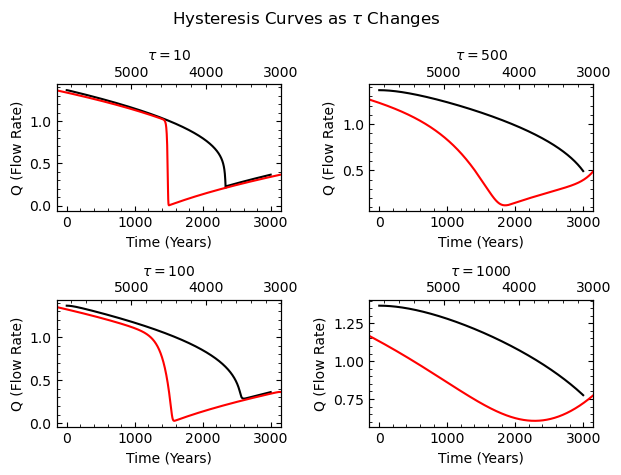

In [ ]:
fig, ax = plt.subplots(2,2)

fig.suptitle(r'Hysteresis Curves as $\tau$ Changes')
# Top Right
ax1l = ax[0,0] 
ax1l.set_xlabel('Time (Years)')
ax1l.set_ylabel('Q (Flow Rate)')
ax1l.plot(tInc, qInc, color='k',label=r'H Inc.')

ax1r = ax1l.twiny()

ax1r.set_xlabel(r'$\tau = 10$')
ax1r.plot(tDec,qDec, color='r',label=r'H Dec.')
ax1r.set_xlim((tDec[-1],tDec[0]))

# Bottom Right
ax1l = ax[1,0] 
ax1l.set_xlabel('Time (Years)')
ax1l.set_ylabel('Q (Flow Rate)')
ax1l.plot(tInc, qInc1, color='k',label=r'H Inc.')

ax1r = ax1l.twiny()

ax1r.set_xlabel(r'$\tau = 100$')
ax1r.plot(tDec,qDec1, color='r',label=r'H Dec.')
ax1r.set_xlim((tDec[-1],tDec[0]))

# Top Left
ax1l = ax[0,1] 
ax1l.set_xlabel('Time (Years)')
ax1l.set_ylabel('Q (Flow Rate)')
ax1l.plot(tInc, qInc2, color='k',label=r'H Inc.')

ax1r = ax1l.twiny()

ax1r.set_xlabel(r'$\tau = 500$')
ax1r.plot(tDec,qDec2, color='r',label=r'H Dec.')
ax1r.set_xlim((tDec[-1],tDec[0]))

# Bottom Left
ax1l = ax[1,1] 
ax1l.set_xlabel('Time (Years)')
ax1l.set_ylabel('Q (Flow Rate)')
ax1l.plot(tInc, qInc3, color='k',label=r'H Inc.')

ax1r = ax1l.twiny()

ax1r.set_xlabel(r'$\tau = 1000$')
ax1r.plot(tDec,qDec3, color='r',label=r'H Dec.')
ax1r.set_xlim((tDec[-1],tDec[0]))

fig.tight_layout()

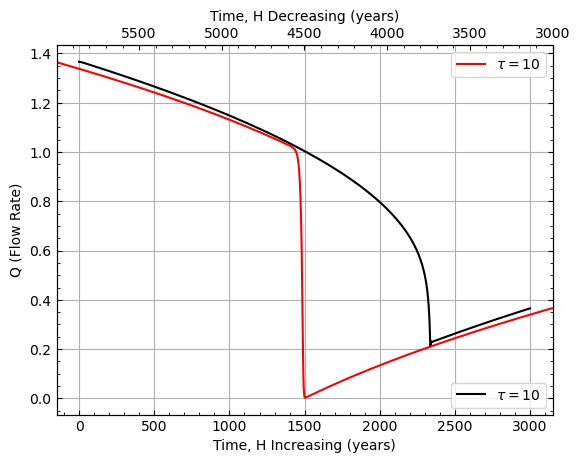

In [51]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(tInc, qInc, color='k',label=r'$\tau = 10$')

ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(tDec,qDec, color='r',label=r'$\tau = 10$')
ax2.set_xlim((tDec[-1],tDec[0]))
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

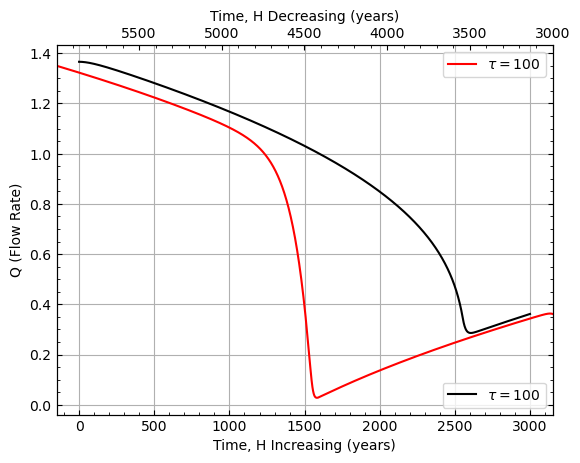

In [53]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(tInc, qInc1, color='k',label=r'$\tau = 100$')



ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(tDec,qDec1, color='r',label=r'$\tau = 100$')
ax2.set_xlim((tDec[-1],tDec[0]))
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

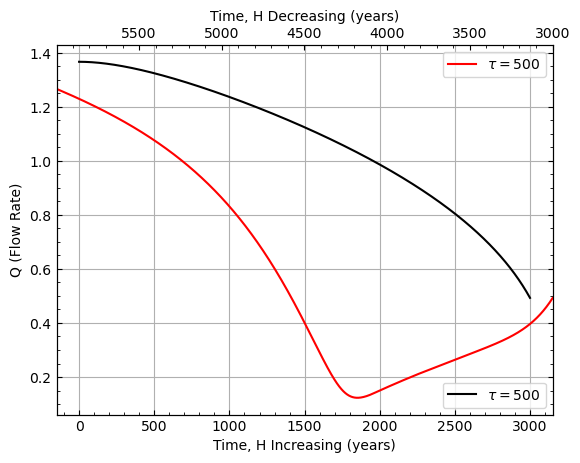

In [54]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(tInc, qInc2, color='k',label=r'$\tau = 500$')


ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(tDec,qDec2, color='r',label=r'$\tau = 500$')
ax2.set_xlim((tDec[-1],tDec[0]))
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

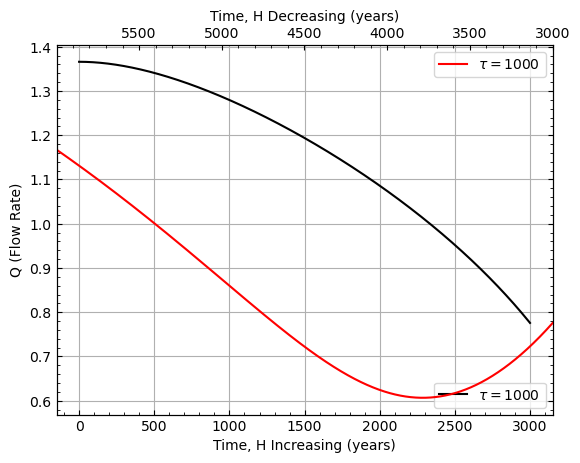

In [55]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(tInc, qInc3, color='k',label=r'$\tau = 1000$')



ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(tDec,qDec3, color='r',label=r'$\tau = 1000$')
ax2.set_xlim((tDec[-1],tDec[0]))
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

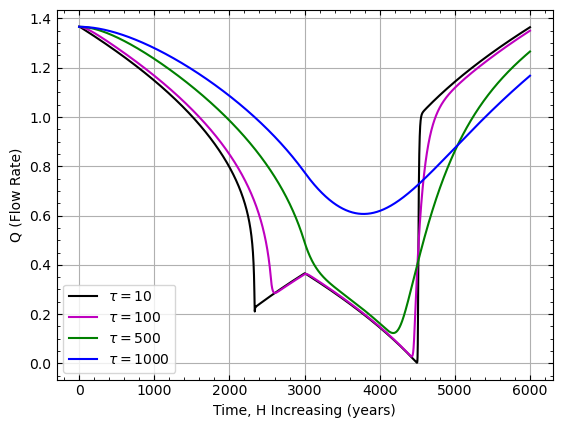

In [56]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')

ax1.plot(sol.t, sol.y[1], color='k',label=r'$\tau = 10$')
ax1.plot(sol.t, sol1.y[1], color='m',label=r'$\tau = 100$')
ax1.plot(sol.t, sol2.y[1], color='g',label=r'$\tau = 500$')
ax1.plot(sol.t, sol3.y[1], color='b',label=r'$\tau = 1000$')

ax1.legend()

In [92]:
def delT(t, n, T_start, T_end):
    
    dT = (T_end - T_start) / (n/2)

    if t <= (n/2):
        T = T_start
    elif t > (n/2):
        T = T_start + (dT*t)
    return T

def dqdtDT(t, y, args, n, H_start, H_end, T_start, T_end, tau):
    '''
    System of equation for AMOC with q, DS, and H as functions of time

    Parameters:
    t: float, time
    y: array of DS, q, and H: y[0]=DS, y[1]=q, y[2]=H
    args: array: [beta, alpha, delT, k]
    n: intended number of samples

    Output:
    dydt: array same shape as y where dydt[i] is the time derivative of y[i]
    '''
    dydt = np.zeros_like(y)
    dydt[0] = 2 * Hs(t, n, H_start, H_end) - 2 * np.absolute(y[1]) * y[0]
    dydt[1] = (-y[1] + args[3] * np.absolute(args[1]*delT(t, n, T_start, T_end) - args[0]*y[0])) / tau
    
    return dydt

In [97]:
n = 6000
H_start = -2
H_end = 2
qinital = q0[0][0]
DSinitial = dSi0 = Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H_start*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0]

y0 = np.array([DSinitial, qinital])

solT = integ.solve_ivp(dqdtDT,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end, 1, -1, 10]), t_eval=(np.arange(n)))

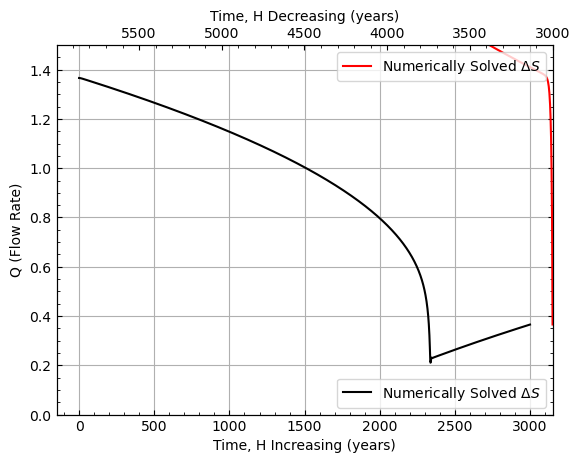

In [100]:
fig, ax1 = plt.subplots()
ax1.grid()

ax1.set_xlabel('Time, H Increasing (years)')
ax1.set_ylabel('Q (Flow Rate)')
ax1.plot(solT.t[:3000], solT.y[1][:3000], color='k',label=r'Numerically Solved $\Delta S$')
ax1.legend(loc='lower right')
ax1.set_ylim(0,1.5)
ax2 = ax1.twiny()

ax2.set_xlabel('Time, H Decreasing (years)')
ax2.plot(solT.t[3000:],solT.y[1][3000:], color='r',label=r'Numerically Solved $\Delta S$')
ax2.set_xlim((solT.t[-1],solT.t[(n//2)]))
ax2.legend(loc='upper right')

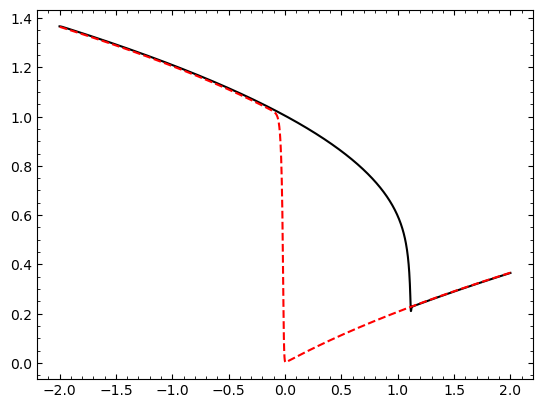

In [ ]:
# Want to see Q vs H for the numerical model:

Hup = np.linspace(-2,2,n//2)
Hdown = np.linspace(2,-2,n//2)
Htest = np.append(Hup,Hdown)

plt.plot(Htest[:3000],sol.y[1][:3000],color='k')
plt.plot(Htest[3000:],sol.y[1][3000:],color='r',ls='--')

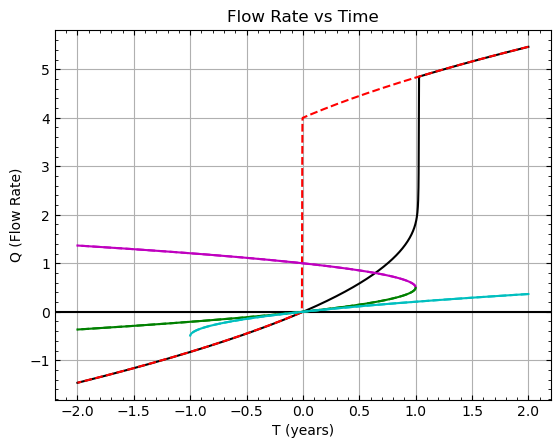

In [148]:
plt.plot(Htest[:3000],solQ.y[0][:3000],color='k')
plt.plot(Htest[3000:],solQ.y[0][3000:],color='r', ls='--')

q0, q1, q2, times, extra= q_H2(Args, -2, 2, 6000)


plt.axhline(0, color='k')
# Graphing the increasing and decreasing sections of 
plt.plot(extra[0], q0[0] , color='m',label='First Stable Inc')
plt.plot(extra[2], q0[1] , color='m',ls='--',label='First Stable Dec')

plt.plot(extra[0], q1[0], color='g',label='Unstable Inc')
plt.plot(extra[2], q1[1], color='g',ls='--',label='Unstable Dec')

plt.plot(extra[1], q2[0], color='c',label='Second Stable Inc')
plt.plot(extra[3], q2[1], color='c',ls='--',label='Second Stable Dec')

plt.title('Flow Rate vs Time')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.grid()
#plt.legend()